Task 1: Load the dataset into a Pandas DataFrame.

In [1]:
import pandas as pd
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Task 2: Use structural inspection methods (head(), info(), describe()) to analyze features such as tenure, MonthlyCharges, TotalCharges, Contract, and PaymentMethod.

In [2]:
print(df.head())
print(df.info())
df.describe()

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Task 3: Drop any non-informative identifiers (such as customerID).

In [3]:
df = df.drop(columns=['customerID'])

Task 4: Quantify any missing or implicit missing values across the columns (handling whitespace strings in TotalCharges) and implement a structured imputation strategy using Scikit-Learn's SimpleImputer.

In [4]:
from sklearn.impute import SimpleImputer

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(df.isna().sum())

imputer = SimpleImputer(strategy='median')
df['TotalCharges'] = imputer.fit_transform(df[['TotalCharges']])

print(df.isna().sum())

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
X = df.drop(columns=['Churn'])
y = df['Churn']

Task 5: Isolate numerical and categorical features, then build a Scikit-Learn ColumnTransformer and Pipeline that applies appropriate scaling (StandardScaler or MinMaxScaler) to numerical columns and encoding (OneHotEncoder) to categorical columns.



In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X = df.drop(columns=['Churn'])
y = df['Churn']


numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numerical_features.remove('SeniorCitizen')
categorical_features.append('SeniorCitizen')

print(numerical_features)
print(categorical_features)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

['tenure', 'MonthlyCharges', 'TotalCharges']
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen']


Task 6: Append an SGDClassifier configured with loss='log_loss' to the end of your pipeline to perform logistic regression and enable probability estimation.

In [7]:
from sklearn.linear_model import SGDClassifier

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SGDClassifier(loss='log_loss', random_state=42))
])

Task 7: Split your dataset into training and test sets using 3 different train/test split ratios (for example, 80/20, 70/30, and 60/40), fit your complete pipeline on each configuration, and evaluate performance using a confusion matrix, classification report, and ROC-AUC curve. Report on any performance differences detected across the various splitting ratios.


--- Split: 80/20 ---
[[943  92]
 [209 165]]
              precision    recall  f1-score   support

          No       0.82      0.91      0.86      1035
         Yes       0.64      0.44      0.52       374

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.69      1409
weighted avg       0.77      0.79      0.77      1409

ROC-AUC: 0.8290087576532588


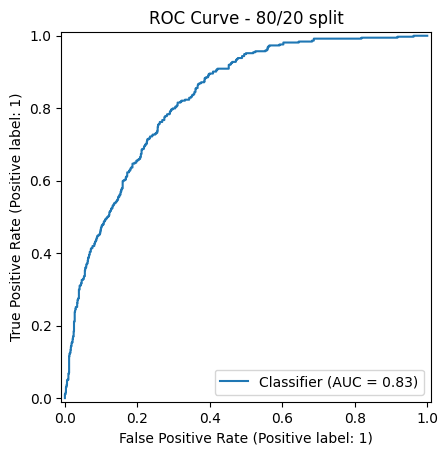


--- Split: 70/30 ---
[[1379  173]
 [ 243  318]]
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1552
         Yes       0.65      0.57      0.60       561

    accuracy                           0.80      2113
   macro avg       0.75      0.73      0.74      2113
weighted avg       0.80      0.80      0.80      2113

ROC-AUC: 0.8440015298528033


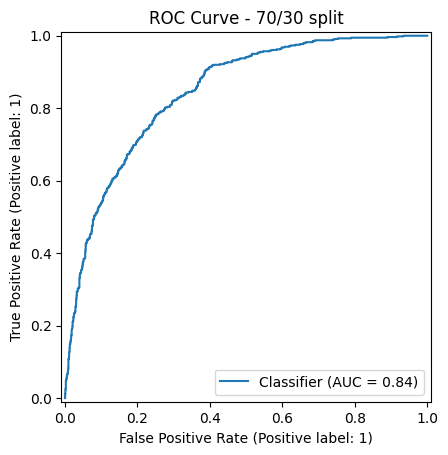


--- Split: 60/40 ---
[[1819  251]
 [ 325  423]]
              precision    recall  f1-score   support

          No       0.85      0.88      0.86      2070
         Yes       0.63      0.57      0.59       748

    accuracy                           0.80      2818
   macro avg       0.74      0.72      0.73      2818
weighted avg       0.79      0.80      0.79      2818

ROC-AUC: 0.8424768787620449


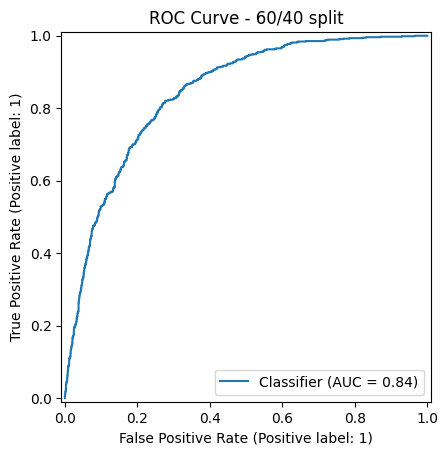

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

split_ratios = [0.2, 0.3, 0.4]  # test sizes for 80/20, 70/30, 60/40

for test_size in split_ratios:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    model = clone(full_pipeline)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n--- Split: {int((1-test_size)*100)}/{int(test_size*100)} ---")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_pred=None, y_score=y_proba) if False else roc_auc_score(y_test.map({'No':0,'Yes':1}), y_proba))

    RocCurveDisplay.from_predictions(y_test.map({'No':0,'Yes':1}), y_proba)
    plt.title(f"ROC Curve - {int((1-test_size)*100)}/{int(test_size*100)} split")
    plt.show()

Task 8: Generate a 2D decision boundary visualization or inspect model feature coefficients to interpret how the model separates churning customers from retained customers.

In [9]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
coefficients = model.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})
coef_df = coef_df.sort_values('coefficient', ascending=False)

print(coef_df.head(10))   # features pushing hardest toward churn
print(coef_df.tail(10))   # features pushing hardest toward staying

                                feature  coefficient
15     cat__InternetService_Fiber optic     1.128308
35         cat__Contract_Month-to-month     0.977216
13               cat__MultipleLines_Yes     0.700328
34             cat__StreamingMovies_Yes     0.649145
45                 cat__SeniorCitizen_1     0.629613
2                     num__TotalCharges     0.628785
31                 cat__StreamingTV_Yes     0.628312
39            cat__PaperlessBilling_Yes     0.623188
42  cat__PaymentMethod_Electronic check     0.617511
10                cat__PhoneService_Yes     0.616858
                                       feature  coefficient
18     cat__OnlineSecurity_No internet service     0.088964
16                     cat__InternetService_No     0.088964
33    cat__StreamingMovies_No internet service     0.088964
24   cat__DeviceProtection_No internet service     0.088964
41  cat__PaymentMethod_Credit card (automatic)    -0.063203
11                       cat__MultipleLines_No    -0.0834